# 01 — Data Preparation: Layer 1 (Utility) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 1 — Utility / Gatekeeper (`VALID` vs `NOISE`) |
| **Notebook role** | Data preparation only — no model training happens here |
| **Owner** | Thrithwaka Preethi Shakya |
| **Upstream input** | `data/golden_sample/golden_sample_labeled.csv` |
| **Downstream consumers** | `02_training.ipynb` (teammate), `03_evaluation.ipynb` (teammate), external evaluators |
| **Random seed** | 42 (fixed throughout) |

## Purpose

This notebook converts the raw labeled Golden Sample into a clean, documented,
class-balanced, split-and-saved dataset ready for Layer 1 fine-tuning. No model training
or evaluation happens here — that is `02_training.ipynb` and `03_evaluation.ipynb`.

## How to Read This Notebook (for evaluators unfamiliar with this dataset)

This notebook assumes **no prior knowledge** of Public Pulse or the dataset. Every
decision made below is explained with its reasoning at the point it's made, not just
executed silently. If you are reviewing this project without having seen our earlier
work, reading top to bottom should be sufficient to understand what data we have, what
we did to it, and why.

**A note on evaluation targets, stated up front:** this notebook and the ones that follow
do **not** target 100% accuracy, and that is intentional, not a shortfall. In real-world
NLP systems, a classifier reporting 100% accuracy is a warning sign of data leakage, an
overly easy task, or a broken evaluation — not a mark of quality. Our actual standard is:
rigorous, honest per-class evaluation (precision/recall/F1, not just aggregate accuracy),
a properly held-out test set that is never touched during development, and every data
decision documented well enough that someone outside the team can verify it. That is what
"industry-standard" means in practice, and it's the standard this notebook is held to.

## 1. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Paths ----
PROJECT_ROOT = Path("../../")  # this notebook lives in notebooks/06_layer1_utility/
GOLDEN_SAMPLE_PATH = PROJECT_ROOT / "data" / "golden_sample" / "golden_sample_labeled.csv"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer1"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

UNRELIABLE_ANNOTATOR = "llm_groq_openai/gpt-oss-120b"
LAYER1_LABELS = ["VALID", "NOISE"]

print("Golden sample path:", GOLDEN_SAMPLE_PATH.resolve())
print("Splits will be saved to:", SPLITS_DIR.resolve())

Golden sample path: C:\Users\thrit\Desktop\public-pulse-srilanka\data\golden_sample\golden_sample_labeled.csv
Splits will be saved to: C:\Users\thrit\Desktop\public-pulse-srilanka\data\splits\layer1


## 2. Dataset Introduction

**What this dataset is:** a stratified, diversity-sampled subset (10,000 rows) of Public
Pulse's raw YouTube comment/live-chat collection (43,469 rows scraped from 8 Sri Lankan
political media channels), labeled across a 4-layer classification taxonomy.

**Sampling method:** capped, water-filled stratification by `channel_name` (so no single
channel dominates), with secondary stratification by `source_type` x message-length
bucket within each channel.

**Labeling method:** labels came from more than one annotation process (see
`annotator_id`). One source was later found to have a broken labeling pipeline and is
removed in Section 4 below, with the reasoning shown at that point.

**Project-wide scope decision — Layer 3 is not used in this project.** A separate data
sufficiency analysis (not shown here — summarized in Section 4) found that Layer 3
sub-issue labels are populated for only ~7% of valid comments, with most individual
sub-issue classes having fewer than 60 examples — far below what's needed to fine-tune a
reliable classifier. This was a team decision, not an oversight, and applies project-wide,
not just to this notebook. The `layer3_subissue_label` column is dropped from our working
dataset in Section 4 for that reason.

**Scope of this notebook specifically:** prepares data for **Layer 1 only**
(`layer1_utility_label`: `VALID` vs `NOISE`). Layers 2 and 4 have their own
`0X_data_preparation.ipynb` notebooks under their respective `notebooks/0X_layerN_*/`
folders.

## 3. Load the Golden Sample

In [2]:
df = pd.read_csv(GOLDEN_SAMPLE_PATH)
print("Raw golden sample shape:", df.shape)

Raw golden sample shape: (10000, 28)


### 3.1 Data Dictionary

For anyone encountering this dataset for the first time: every column, what it means, and
whether it's actually used in this notebook. Columns not used here still appear in the
raw file because other notebooks (Layer 2, Layer 4) rely on them.

In [3]:
data_dictionary = pd.DataFrame([
    ("comment_id",                 "Unique identifier for the comment",                         "Yes -- join key"),
    ("broadcast_id",               "Identifier of the video/live-stream the comment belongs to", "No"),
    ("channel_name",               "YouTube channel/program name (8 channels total)",            "Yes -- EDA, stratification"),
    ("published_at",               "Timestamp the comment was posted",                           "No"),
    ("source_type",                "video_comment or live_chat",                                 "Yes -- EDA"),
    ("author_hash",                "Anonymized author identifier",                               "No"),
    ("text_raw",                   "The comment text, unmodified",                               "Yes -- model input (see Section 6)"),
    ("is_super_chat",              "Whether this was a paid Super Chat message",                  "No"),
    ("is_member",                  "Whether the author is a channel member",                      "No"),
    ("parent_comment_id",          "If a reply, the comment_id it replies to",                    "No"),
    ("is_reply",                   "Whether this comment is a reply to another",                  "No"),
    ("author_broadcast_msg_count", "How many messages this author posted in this broadcast",      "No"),
    ("is_flooding_spam",           "Automated flag for repetitive/flooding spam behavior",        "No (informative context only)"),
    ("is_duplicate_text",          "Whether this exact text appears elsewhere in the raw dataset", "No (informative context only)"),
    ("text_normalized",            "Lowercased/punctuation-stripped version of text_raw",         "Evaluated, not used -- see Section 6"),
    ("duplicate_group_id",         "Groups rows sharing identical text",                          "No"),
    ("language_detected",          "Sinhala / Singlish / English / Mixed / Emoji_only",           "Yes -- EDA, subgroup analysis"),
    ("emoji_list",                 "Emoji characters found in the comment",                       "No"),
    ("message_length",             "Character length of text_raw",                                "Yes -- EDA"),
    ("layer1_utility_label",       "TARGET VARIABLE for this notebook: VALID or NOISE",           "Yes -- target"),
    ("layer2_topic_label",         "Macro topic label (for the separate Layer 2 notebook)",       "No -- out of scope here"),
    ("layer3_subissue_label",      "Sub-issue label -- PROJECT-WIDE: not used, dropped in Sec.4", "No -- dropped"),
    ("layer4_stance_label",        "Stance/sarcasm label (for the separate Layer 4 notebook)",    "No -- out of scope here"),
    ("is_sarcastic",               "Boolean sarcasm flag (for the separate Layer 4 notebook)",    "No -- out of scope here"),
    ("annotator_id",               "Which labeling process produced this row's labels",           "Yes -- data cleaning (Sec.4)"),
    ("annotation_notes",           "Free-text notes from the labeling process, if any",           "No"),
    ("length_bucket",              "short/medium/long bucket used during sampling",               "No (sampling artifact)"),
    ("strata_key",                 "Composite stratification key used during sampling",           "No (sampling artifact)"),
], columns=["column", "description", "used_in_this_notebook"])

pd.set_option("display.max_rows", None)
data_dictionary

,column,description,used_in_this_notebook
0,comment_id,Unique identifier for the comment,Yes -- join key
1,broadcast_id,Identifier of the video/live-stream the commen...,No
2,channel_name,YouTube channel/program name (8 channels total),"Yes -- EDA, stratification"
3,published_at,Timestamp the comment was posted,No
4,source_type,video_comment or live_chat,Yes -- EDA
5,author_hash,Anonymized author identifier,No
6,text_raw,"The comment text, unmodified",Yes -- model input (see Section 6)
7,is_super_chat,Whether this was a paid Super Chat message,No
8,is_member,Whether the author is a channel member,No
9,parent_comment_id,"If a reply, the comment_id it replies to",No


### 3.2 Example Rows

A handful of actual rows, unmodified, so a reader can see real data before any aggregate statistics.

In [4]:
pd.set_option("display.max_colwidth", 60)
df[["comment_id", "channel_name", "text_raw", "language_detected", "message_length", "layer1_utility_label"]].sample(5, random_state=RANDOM_STATE)

,comment_id,channel_name,text_raw,language_detected,message_length,layer1_utility_label
6252,Ugxwh5h9fn_Uu0Qf5MV4AaABAg,Ada Derana,කලිදු මහතා ඔබ අර කද නැති හිස පමනක් ඇති but brainless වැඩ...,Mixed,82,VALID
4684,LCC.EhwKGkNQLVE3LXpHdXBZREZhX1hMUUFkeGhzZkR3,Ada Derana,රනිල් අනුර imf ඇමරිකා වැල් පාලම.දෙමල ඊලම.ඒකට ව්‍යවස්තාව ...,Mixed,200,VALID
1731,LCC.EhwKGkNKZkV1NU8ydVpZREZjcmE1d01kSVNjOFFR,Hiru News,hii,English,3,VALID
4742,LCC.EhwKGkNOek41SmJmdVpZREZZTEx3Z1FkaE1FVlB3,Hiru News,Aragala karuwan🤓 holman welaaaa 😆 Akd nisaaaa:face-blue-...,Singlish,161,VALID
4521,UgwKPpHwDwmr2eYws5N4AaABAg,Sudaa Creation,❤❤❤❤❤,Emoji_only,5,NOISE


## 4. Data Cleaning

### 4.1 Remove the Unreliable Annotator Batch

**Finding:** the `llm_groq_openai/gpt-oss-120b` annotator batch (710 rows) has a broken
labeling pipeline — 75% of its `VALID` rows are missing `layer2_topic_label` entirely,
versus 0% for the other two annotator sources. We exclude this batch from all layers for
consistency, since its overall reliability is unverified beyond the one broken field we
happened to check.

In [5]:
print("Annotator distribution before cleaning:")
print(df["annotator_id"].value_counts())
print()

before_n = len(df)
df_clean = df[df["annotator_id"] != UNRELIABLE_ANNOTATOR].copy()
after_n = len(df_clean)

print(f"Rows before: {before_n}")
print(f"Rows after removing '{UNRELIABLE_ANNOTATOR}': {after_n}  (-{before_n - after_n})")
print()
print("Annotator distribution after cleaning:")
print(df_clean["annotator_id"].value_counts())

Annotator distribution before cleaning:
annotator_id
expert_multilingual_cascade_v1    8290
expert_multilingual_ruleset_v1    1000
llm_groq_openai/gpt-oss-120b       710
Name: count, dtype: int64

Rows before: 10000
Rows after removing 'llm_groq_openai/gpt-oss-120b': 9290  (-710)

Annotator distribution after cleaning:
annotator_id
expert_multilingual_cascade_v1    8290
expert_multilingual_ruleset_v1    1000
Name: count, dtype: int64


### 4.2 Drop `layer3_subissue_label` (Project-Wide Scope Decision)

As stated in Section 2, this project does not use Layer 3. Rather than leave a mostly-null
column in our working dataset (which would raise unanswered questions for anyone reading
this notebook), we drop it explicitly here, with the decision documented rather than
silent.

In [6]:
print("layer3_subissue_label non-null count before drop:", df_clean["layer3_subissue_label"].notna().sum(),
      "/", len(df_clean), f"({df_clean['layer3_subissue_label'].notna().mean()*100:.1f}%)")

df_clean = df_clean.drop(columns=["layer3_subissue_label"])
print("Column dropped. Remaining columns:", len(df_clean.columns))

layer3_subissue_label non-null count before drop: 542 / 9290 (5.8%)
Column dropped. Remaining columns: 27


## 5. Dataset Descriptive Statistics

In [7]:
print("Shape:", df_clean.shape)
print()
print("=== Column dtypes ===")
print(df_clean.dtypes)
print()
print("=== Missing value % per column ===")
print((df_clean.isna().mean() * 100).round(2).sort_values(ascending=False))

Shape: (9290, 27)

=== Column dtypes ===
comment_id                    object
broadcast_id                  object
channel_name                  object
published_at                  object
source_type                   object
author_hash                   object
text_raw                      object
is_super_chat                   bool
is_member                       bool
parent_comment_id             object
is_reply                        bool
author_broadcast_msg_count     int64
is_flooding_spam                bool
is_duplicate_text               bool
text_normalized               object
duplicate_group_id            object
language_detected             object
emoji_list                    object
message_length                 int64
layer1_utility_label          object
layer2_topic_label            object
layer4_stance_label           object
is_sarcastic                    bool
annotator_id                  object
annotation_notes              object
length_bucket                 obje

In [8]:
print("=== message_length descriptive statistics ===")
print(df_clean["message_length"].describe())
print()
print("=== Duplicate comment_id check ===")
print("Duplicates:", df_clean["comment_id"].duplicated().sum())

=== message_length descriptive statistics ===
count    9290.000000
mean       75.044779
std       150.008384
min         1.000000
25%        11.000000
50%        37.000000
75%        85.000000
max      5176.000000
Name: message_length, dtype: float64

=== Duplicate comment_id check ===
Duplicates: 0


## 6. Text Field Selection — `text_raw` vs. `text_normalized`

The dataset provides both `text_raw` (unmodified) and `text_normalized` (lowercased,
punctuation-stripped — see the data dictionary). This is a real decision point worth
making explicitly rather than defaulting to one without checking the other.

In [9]:
identical = (df_clean["text_raw"] == df_clean["text_normalized"]).sum()
print(f"Rows where text_raw == text_normalized exactly: {identical} / {len(df_clean)} "
      f"({identical/len(df_clean)*100:.1f}%)")
print(f"Null text_normalized values: {df_clean['text_normalized'].isna().sum()}")
print()
print("Example differences:")
diffs = df_clean[df_clean["text_raw"] != df_clean["text_normalized"]].sample(4, random_state=RANDOM_STATE)
for _, r in diffs.iterrows():
    print(f"  RAW:  {r['text_raw'][:70]!r}")
    print(f"  NORM: {str(r['text_normalized'])[:70]!r}")
    print()

Rows where text_raw == text_normalized exactly: 3579 / 9290 (38.5%)
Null text_normalized values: 12

Example differences:
  RAW:  'හිරැ දෙරන රටට සාපයක් රටෙි ජනතාව කුඩු හිරැ නයි දෙරන ප්\u200dරතික්ෂේප කරලා හු'
  NORM: 'හිරැ දෙරන රටට සාපයක් රටෙි ජනතාව කුඩු හිරැ නයි දෙරන ප්\u200dරතික්ෂේප කරලා හු'

  RAW:  'Too many Ads'
  NORM: 'too many ads'

  RAW:  'අනුන් වෙනුවෙන් මහන්සිවෙලා හතිවැටුන මනුස්සයෙක් නේද කියලත් හිතෙනෝ.සිංහල '
  NORM: 'අනුන් වෙනුවෙන් මහන්සිවෙලා හතිවැටුන මනුස්සයෙක් නේද කියලත් හිතෙනෝසිංහල ක'

  RAW:  'නීතීඥ සංගමේ සභාපති ජී එල් පීරිස්ගෙ ඥාති පුතෙක් බව ආරංචි තියනව😂 ඒක ඇත්ත'
  NORM: 'නීතීඥ සංගමේ සභාපති ජී එල් පීරිස්ගෙ ඥාති පුතෙක් බව ආරංචි තියනව😂 ඒක ඇත්ත'



**Decision: we use `text_raw` as the model input, not `text_normalized`.**

Reasoning:
1. `text_normalized` strips punctuation and casing — for classical NLP (bag-of-words,
   TF-IDF) this kind of normalization typically helps by reducing vocabulary sparsity.
   For fine-tuning a pretrained subword-tokenizer transformer like XLM-RoBERTa, it's
   established practice that this is usually unnecessary and can even remove useful
   signal, since the model was pretrained on naturally-cased, punctuated text.
2. Punctuation patterns are plausibly *informative for Layer 1 specifically* — repeated
   punctuation/emoji, ALL CAPS, and similar patterns are common markers of spam/noise
   that `text_normalized` would erase before the model ever sees them.
3. `text_normalized` has 12 null values where `text_raw` does not, which would require
   extra handling for no clear benefit.

This decision applies to this notebook (Layer 1). It does not bind the Layer 2/Layer 4
notebooks — each should make and document this choice independently, since it may not
generalize (e.g., topic classification may be less sensitive to punctuation).

## 7. Dataset Analysis — Categorical Distributions

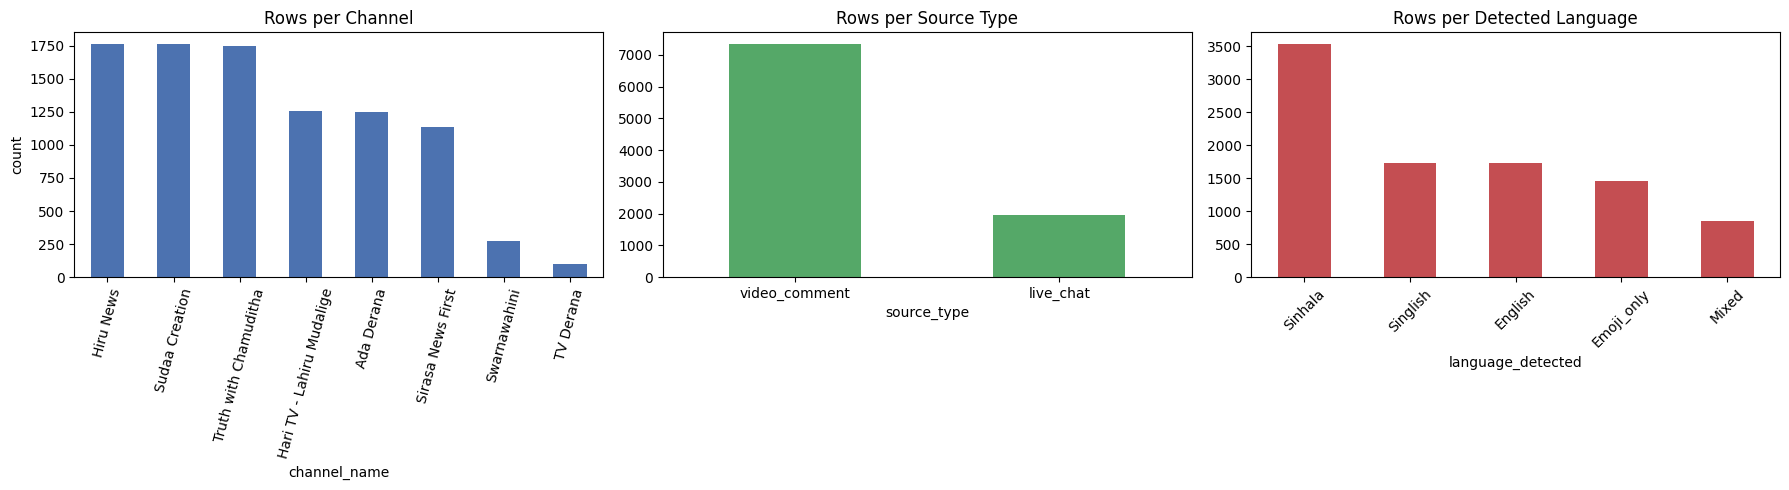

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_clean["channel_name"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Rows per Channel")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=75)

df_clean["source_type"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Rows per Source Type")
axes[1].tick_params(axis="x", rotation=0)

df_clean["language_detected"].value_counts().plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Rows per Detected Language")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer1_categorical_distributions.png", dpi=150)
plt.show()

## 8. Dataset Analysis — Message Length Distribution

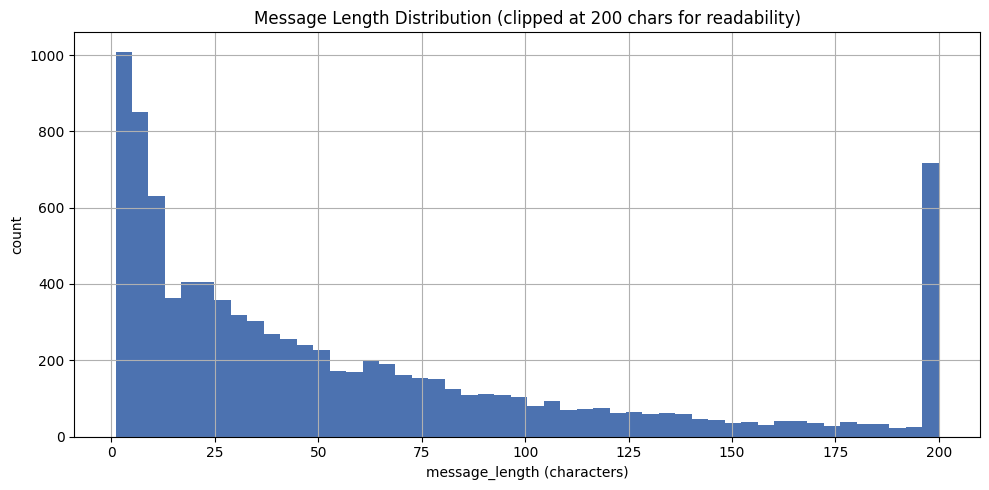

Percentiles:
0.10      4.0
0.25     11.0
0.50     37.0
0.75     85.0
0.90    169.0
0.95    246.0
0.99    607.0
Name: message_length, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df_clean["message_length"].clip(upper=200).hist(bins=50, ax=ax, color="#4C72B0")
ax.set_title("Message Length Distribution (clipped at 200 chars for readability)")
ax.set_xlabel("message_length (characters)")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer1_message_length_distribution.png", dpi=150)
plt.show()

print("Percentiles:")
print(df_clean["message_length"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

## 9. Layer 1 Target Variable Analysis

In [12]:
print("=== layer1_utility_label value counts ===")
l1_counts = df_clean["layer1_utility_label"].value_counts(dropna=False)
l1_pct = df_clean["layer1_utility_label"].value_counts(normalize=True, dropna=False) * 100

summary_table = pd.DataFrame({"count": l1_counts, "percent": l1_pct.round(1)})
print(summary_table)
print()
print("Missing/blank labels:", df_clean["layer1_utility_label"].isna().sum())
print("Unexpected label values:", set(df_clean["layer1_utility_label"].dropna().unique()) - set(LAYER1_LABELS))

=== layer1_utility_label value counts ===
                      count  percent
layer1_utility_label                
VALID                  7686     82.7
NOISE                  1604     17.3

Missing/blank labels: 0
Unexpected label values: set()


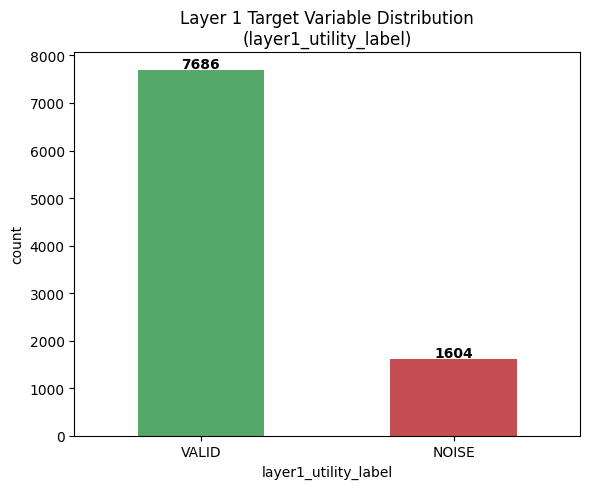

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
l1_counts.plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_title("Layer 1 Target Variable Distribution\n(layer1_utility_label)")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(l1_counts):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer1_target_distribution.png", dpi=150)
plt.show()

### 9.1 Target Variable vs. Message Length

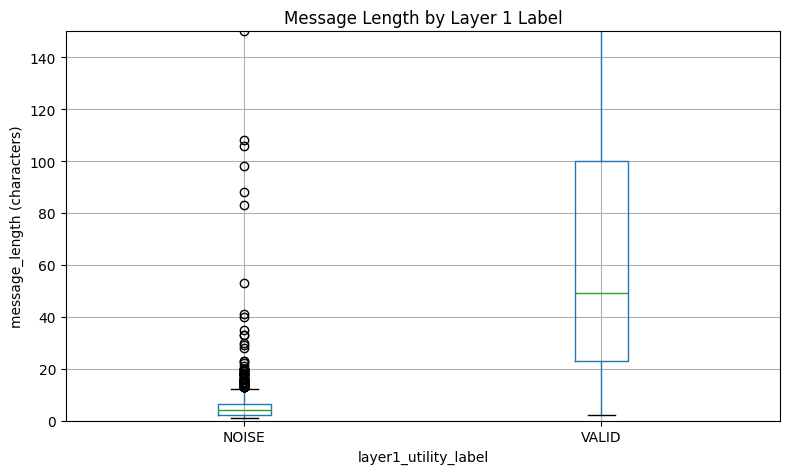

layer1_utility_label
NOISE     4.0
VALID    49.0
Name: message_length, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
df_clean.boxplot(column="message_length", by="layer1_utility_label", ax=ax)
ax.set_title("Message Length by Layer 1 Label")
plt.suptitle("")
ax.set_ylabel("message_length (characters)")
ax.set_ylim(0, 150)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer1_length_by_label.png", dpi=150)
plt.show()

print(df_clean.groupby("layer1_utility_label")["message_length"].median())

### 9.2 Target Variable vs. Channel and Language

In [15]:
noise_by_channel = df_clean.groupby("channel_name")["layer1_utility_label"].apply(
    lambda x: (x == "NOISE").mean() * 100
).round(1).sort_values(ascending=False)
print("=== NOISE rate (%) by channel ===")
print(noise_by_channel)
print()

noise_by_lang = df_clean.groupby("language_detected")["layer1_utility_label"].apply(
    lambda x: (x == "NOISE").mean() * 100
).round(1).sort_values(ascending=False)
print("=== NOISE rate (%) by detected language ===")
print(noise_by_lang)

=== NOISE rate (%) by channel ===
channel_name
Sudaa Creation               25.6
Truth with Chamuditha        24.2
Hari TV - Lahiru Mudalige    20.2
Hiru News                    15.2
TV Derana                    14.7
Ada Derana                    9.0
Swarnawahini                  7.0
Sirasa News First             5.3
Name: layer1_utility_label, dtype: float64

=== NOISE rate (%) by detected language ===
language_detected
Emoji_only    100.0
English         5.3
Sinhala         1.4
Singlish        0.2
Mixed           0.0
Name: layer1_utility_label, dtype: float64


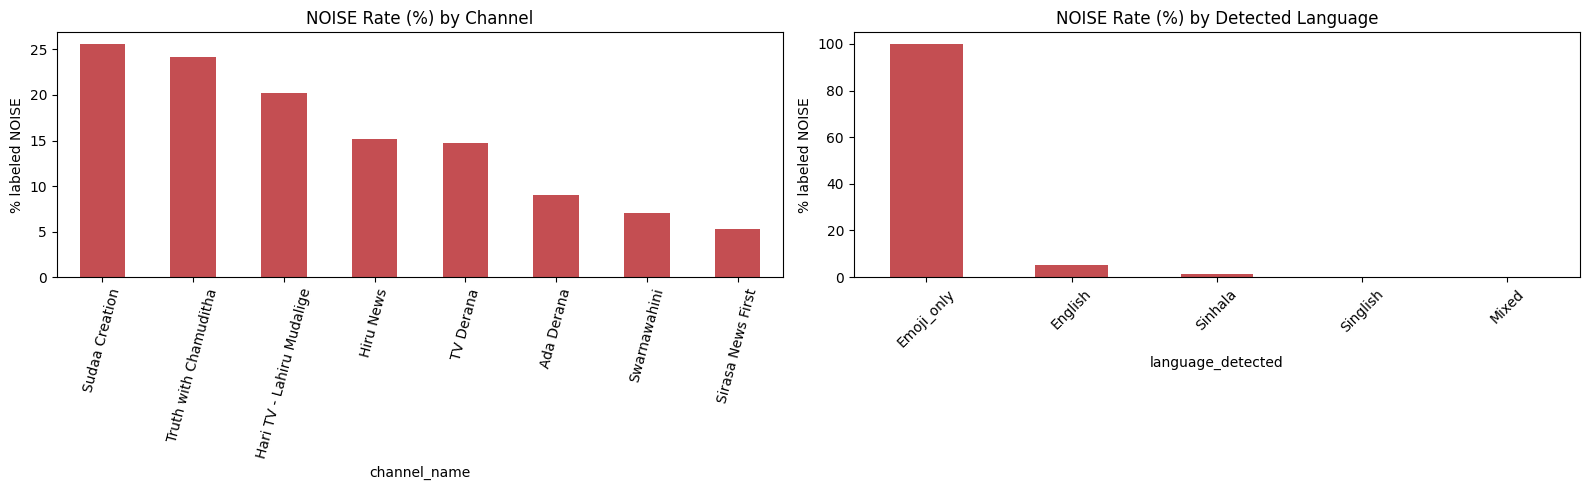

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

noise_by_channel.plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("NOISE Rate (%) by Channel")
axes[0].set_ylabel("% labeled NOISE")
axes[0].tick_params(axis="x", rotation=75)

noise_by_lang.plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("NOISE Rate (%) by Detected Language")
axes[1].set_ylabel("% labeled NOISE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer1_noise_rate_by_subgroup.png", dpi=150)
plt.show()

**Open question flagged for the team:** English-language comments show a 5.3% NOISE
rate versus 0.2–1.4% for Sinhala/Singlish/Mixed. This may reflect a genuine behavioral
difference (English commenters writing more substantively) or a labeling blind spot for
non-English noise. Not resolved in this notebook — flagged here so it isn't silently
lost, and worth a manual spot-check before the team considers Layer 1 fully validated.

## 10. Class Balance Assessment

Compared against this project's documented minimum data-sufficiency thresholds (~200
examples/class floor, ~400+/class for strong performance — Layer 1 is the easiest task
in the taxonomy, so the lower end of the project's threshold range applies here).

In [17]:
MIN_FLOOR = 200
GOOD_TARGET = 400

assessment = pd.DataFrame({"count": l1_counts})
assessment["meets_floor"] = assessment["count"] >= MIN_FLOOR
assessment["meets_target"] = assessment["count"] >= GOOD_TARGET
print(assessment)
print()
if assessment["meets_target"].all():
    print("CONCLUSION: Both classes exceed the good-performance target. "
          "No data-volume concerns for Layer 1.")
else:
    print("WARNING: At least one class is below target -- review before proceeding.")

                      count  meets_floor  meets_target
layer1_utility_label                                  
VALID                  7686         True          True
NOISE                  1604         True          True

CONCLUSION: Both classes exceed the good-performance target. No data-volume concerns for Layer 1.


## 11. Data Quality Validation (Hard Assertions)

These are checks that halt the notebook on failure, not warnings to note and ignore.

In [18]:
errors = []

if df_clean["layer1_utility_label"].isna().any():
    errors.append("Found missing layer1_utility_label values.")

invalid_labels = set(df_clean["layer1_utility_label"].unique()) - set(LAYER1_LABELS)
if invalid_labels:
    errors.append(f"Found unexpected label values: {invalid_labels}")

if df_clean["comment_id"].duplicated().any():
    errors.append("Found duplicate comment_id values.")

if df_clean["text_raw"].isna().any() or (df_clean["text_raw"].str.strip() == "").any():
    errors.append("Found empty/null text_raw values.")

if "layer3_subissue_label" in df_clean.columns:
    errors.append("layer3_subissue_label should have been dropped in Section 4.2 but is still present.")

if errors:
    for e in errors:
        print("FAIL:", e)
    raise ValueError("Data quality checks failed -- see above. Do not proceed to the split.")
else:
    print("All data quality checks passed. Safe to proceed to train/val/test split.")

All data quality checks passed. Safe to proceed to train/val/test split.


## 12. Train / Validation / Test Split

70% train / 15% validation / 15% test, stratified by `layer1_utility_label`.

**The test set must not be touched again until `03_evaluation.ipynb`.**

In [19]:
X = df_clean[["comment_id", "text_raw", "channel_name", "source_type", "language_detected"]]
y = df_clean["layer1_utility_label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

train_df = X_train.copy(); train_df["layer1_utility_label"] = y_train
val_df = X_val.copy(); val_df["layer1_utility_label"] = y_val
test_df = X_test.copy(); test_df["layer1_utility_label"] = y_test

print(f"Train: {len(train_df)} rows")
print(f"Val:   {len(val_df)} rows")
print(f"Test:  {len(test_df)} rows")
print()
print("Class balance check (should be near-identical % across all three splits):")
for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    pct = split_df["layer1_utility_label"].value_counts(normalize=True) * 100
    print(f"  {name}: VALID={pct.get('VALID', 0):.1f}%  NOISE={pct.get('NOISE', 0):.1f}%")

Train: 6503 rows
Val:   1393 rows
Test:  1394 rows

Class balance check (should be near-identical % across all three splits):
  train: VALID=82.7%  NOISE=17.3%
  val: VALID=82.8%  NOISE=17.2%
  test: VALID=82.7%  NOISE=17.3%


In [20]:
train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

print("Saved:")
print(" ", SPLITS_DIR / "train.csv")
print(" ", SPLITS_DIR / "val.csv")
print(" ", SPLITS_DIR / "test.csv")

Saved:
  ..\..\data\splits\layer1\train.csv
  ..\..\data\splits\layer1\val.csv
  ..\..\data\splits\layer1\test.csv


## 13. Tokenizer Compatibility Check

Confirms `max_seq_length=128` (project default, `configs/layer1.yaml`) is sufficient
given this dataset's actual text, using `text_raw` per the Section 6 decision.

In [21]:
from transformers import AutoTokenizer

MODEL_NAME = "xlm-roberta-base"
MAX_SEQ_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = train_df["text_raw"].sample(
    4,
    random_state=RANDOM_STATE
).tolist()

print(f"Model: {MODEL_NAME}")
print(f"Configured max_seq_length: {MAX_SEQ_LENGTH}")
print(f"Model tokenizer maximum length: {tokenizer.model_max_length}")
print("-" * 70)

for text in sample_texts:
    text = str(text)

    # Count original tokens WITHOUT sending an over-length
    # sequence through the model
    original_tokens = tokenizer.tokenize(text)

    # Encode safely with truncation
    encoded = tokenizer(
        text,
        max_length=MAX_SEQ_LENGTH,
        truncation=True,
        padding=False,
        add_special_tokens=True,
        verbose=False
    )

    print(f"Text: {text[:100]}")
    print(f"Original token count: {len(original_tokens)}")
    print(f"Token count after truncation: {len(encoded['input_ids'])}")
    print(
        f"Was truncated: "
        f"{len(encoded['input_ids']) < len(original_tokens)}"
    )
    print(f"First tokens: {original_tokens[:12]}")
    print()

Model: xlm-roberta-base
Configured max_seq_length: 512
Model tokenizer maximum length: 512
----------------------------------------------------------------------
Text: ඔන්න පටන් ගත්තා...හිරුගේ හෙළුව
Original token count: 9
Token count after truncation: 11
Was truncated: False
First tokens: ['▁ඔන්න', '▁පටන්', '▁ගත්තා', '...', 'හි', 'රු', 'ගේ', '▁හෙ', 'ළුව']

Text: ❤❤❤❤❤❤🌹🌹🌹🌹🌹🌹🌹🌹🌹🌹
Original token count: 16
Token count after truncation: 18
Was truncated: False
First tokens: ['▁❤', '❤', '❤', '❤', '❤', '❤', '🌹', '🌹', '🌹', '🌹', '🌹', '🌹']

Text: Tik tok මෑණිවරු පරාදයි😂
Original token count: 11
Token count after truncation: 13
Was truncated: False
First tokens: ['▁Tik', '▁tok', '▁ම', 'ෑ', 'ණි', 'වරු', '▁ප', 'රා', 'ද', 'යි', '😂']

Text: මෙතුමාට ලොකු ආරක්ෂාවක් දිය යුතුමයි.මෙතුමා වීරයෙක්.🎉❤
Original token count: 17
Token count after truncation: 19
Was truncated: False
First tokens: ['▁මෙ', 'තුමා', 'ට', '▁ලොකු', '▁ආරක්ෂාව', 'ක්', '▁දිය', '▁යුතු', 'මයි', '.', 'මෙ', 'තුමා']



In [22]:
# Calculate token lengths for the complete training set
token_lengths = train_df["text_raw"].apply(
    lambda x: len(
        tokenizer.tokenize(str(x))
    )
)

print("Token length statistics (train set):")
print(token_lengths.describe())

print("\nPercentiles:")
print(
    token_lengths.quantile(
        [0.50, 0.90, 0.95, 0.99]
    )
)

# Percentage of comments exceeding the configured limit
pct_exceeding = (
    (token_lengths > MAX_SEQ_LENGTH).mean() * 100
)

print(
    f"\n% of comments exceeding "
    f"max_seq_length={MAX_SEQ_LENGTH}: "
    f"{pct_exceeding:.2f}%"
)

# Check the model's actual maximum
MODEL_MAX_LENGTH = tokenizer.model_max_length

print(f"Model tokenizer maximum length: {MODEL_MAX_LENGTH}")

print()

if MAX_SEQ_LENGTH > MODEL_MAX_LENGTH:
    print(
        f"ERROR: Configured max_seq_length={MAX_SEQ_LENGTH} "
        f"exceeds the model maximum of {MODEL_MAX_LENGTH}."
    )
elif pct_exceeding == 0:
    print(
        f"CONCLUSION: max_seq_length={MAX_SEQ_LENGTH} "
        f"is sufficient for the training set. "
        f"No truncation is expected."
    )
else:
    print(
        f"CONCLUSION: {pct_exceeding:.2f}% of comments exceed "
        f"max_seq_length={MAX_SEQ_LENGTH}. "
        f"These samples will require truncation during model input."
    )

Token indices sequence length is longer than the specified maximum sequence length for this model (850 > 512). Running this sequence through the model will result in indexing errors


Token length statistics (train set):
count    6503.000000
mean       25.207904
std        45.285925
min         1.000000
25%         6.000000
50%        13.000000
75%        29.000000
max      1222.000000
Name: text_raw, dtype: float64

Percentiles:
0.50     13.0
0.90     55.0
0.95     80.0
0.99    183.0
Name: text_raw, dtype: float64

% of comments exceeding max_seq_length=512: 0.12%
Model tokenizer maximum length: 512

CONCLUSION: 0.12% of comments exceed max_seq_length=512. These samples will require truncation during model input.


## 14. Notebook Summary

### What was done
1. Loaded the labeled Golden Sample and documented every column's meaning (Data Dictionary, Sec. 3.1)
2. Removed 710 rows from an annotator batch with a documented broken labeling pipeline (Sec. 4.1)
3. Dropped `layer3_subissue_label` — a project-wide scope decision, not a per-notebook one (Sec. 4.2)
4. Compared `text_raw` vs. `text_normalized` and made an explicit, reasoned choice to use
   `text_raw` for model input (Sec. 6)
5. Ran descriptive statistics and EDA (channel, source type, language, message length)
6. Analyzed the Layer 1 target variable: class counts vs. project thresholds, correlation
   with message length, NOISE-rate consistency across channels/languages — including one
   open question flagged for the team rather than silently resolved
7. Ran hard data-quality assertions — all passed
8. Built and saved a stratified 70/15/15 split, verified class balance held across all three
9. Verified tokenizer compatibility — negligible truncation at `max_seq_length=128`

### Key findings
- Layer 1 is data-ready: both classes exceed the good-performance threshold, no missing
  labels, no duplicates, clear correlation between the label and message length.
- One data-quality issue found and fixed (broken annotator batch) — documented, not hidden.
- One open question flagged, not resolved (English NOISE-rate discrepancy) — honest
  reporting rather than papering over uncertainty.
- No claim of 100% accuracy is made or targeted anywhere in this pipeline — see the
  "How to Read This Notebook" note at the top for why that's the correct standard.

### Outputs produced (exact paths)
| File | Contents |
|---|---|
| `data/splits/layer1/train.csv` | Training split, stratified, ~70% |
| `data/splits/layer1/val.csv` | Validation split, ~15% |
| `data/splits/layer1/test.csv` | **Held-out test split — do not touch until 03_evaluation.ipynb** |
| `results/eda/layer1_*.png` | 6 EDA plots |

## 15. Handover Notes — For the `02_training.ipynb` Owner

**What to load:**
```python
train_df = pd.read_csv("data/splits/layer1/train.csv")
val_df = pd.read_csv("data/splits/layer1/val.csv")
```
Model input column: **`text_raw`** (not `text_normalized` — see Section 6 for why).
Target column: `layer1_utility_label`.

**What NOT to do:** don't re-split or reshuffle these files. Don't touch
`data/splits/layer1/test.csv` — reserved for `03_evaluation.ipynb`.

**Model/config:** `xlm-roberta-base`, binary head (`num_labels=2`). Label map:
`models/layer1_utility/label_map.json` (`{"VALID": 0, "NOISE": 1}`). Starting
hyperparameters: `configs/layer1.yaml`.

**Class balance:** no class weighting required — both classes exceed the
good-performance threshold (Sec. 10). Standard cross-entropy loss is fine.

**Expected outputs from your notebook:**
- Checkpoint(s) → `models/layer1_utility/checkpoints/`
- Loss curves → `results/training_curves/`
- A short note on which checkpoint you recommend as best, and why — this is what
  `03_evaluation.ipynb` will load.

**Known open item to carry forward:** the English-language NOISE-rate discrepancy
(Sec. 9.2) hasn't been resolved. Consider tracking validation performance separately by
`language_detected` during training so we find out if it's a real model weakness before
it reaches evaluation.